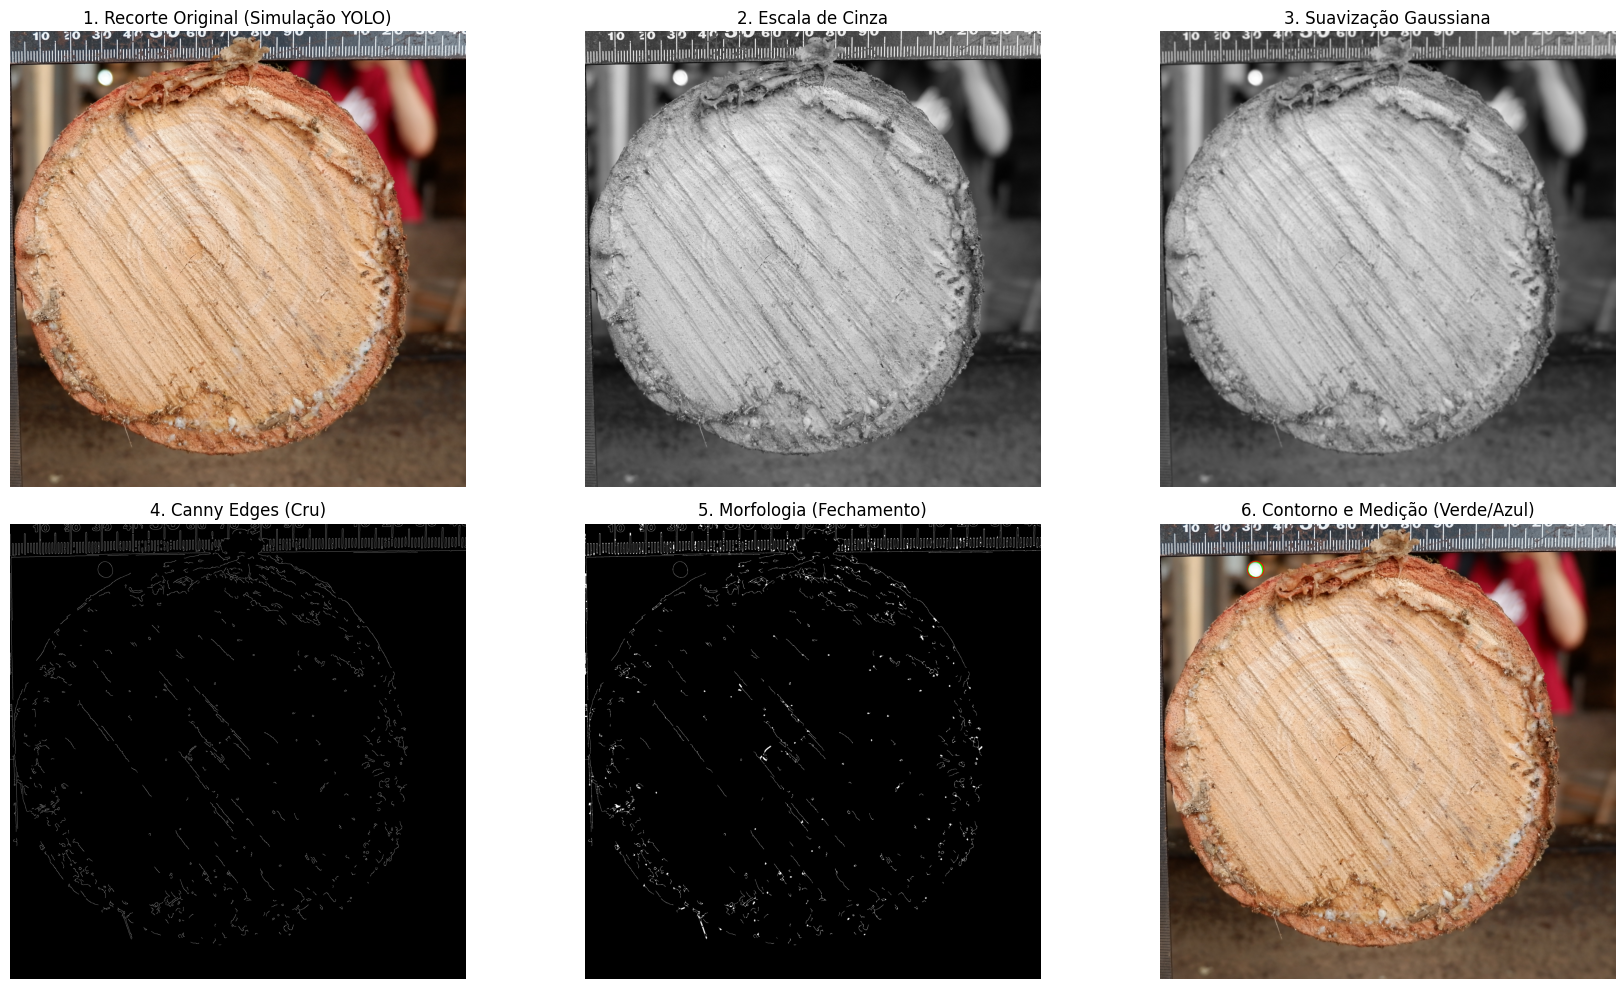

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

# 1. Carregar uma imagem do dataset
caminho_imagens = glob.glob("../data/raw/train/images/*.jpg")
if not caminho_imagens:
    print("Imagem não encontrada!")
else:
    img_path = caminho_imagens[0]
    img = cv2.imread(img_path)
    
    # ---------------------------------------------------------
    # SIMULAÇÃO DO YOLO (Recorte da Região de Interesse)
    # Como o modelo ainda está treinando, pegamos o centro da imagem
    # ---------------------------------------------------------
    h, w = img.shape[:2]
    y1, y2 = int(h * 0.15), int(h * 0.9)  # Corta margens verticais
    x1, x2 = int(w * 0.3), int(w * 0.8)   # Corta margens horizontais
    
    crop_bgr = img[y1:y2, x1:x2]
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)

    # =========================================================
    # AS 5 TÉCNICAS DE PDI
    # =========================================================

    # TÉCNICA 1: Conversão para Escala de Cinza (Grayscale)
    # Motivo: O Canny funciona baseado em gradientes de intensidade (luz), a cor não importa aqui.
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)

    # TÉCNICA 2: Filtro Espacial de Suavização (Gaussian Blur)
    # Motivo: Borrar a imagem tira o detalhe dos "anéis" internos da madeira, que confundiriam o Canny.
    blur = cv2.GaussianBlur(gray, (15, 15), 0)

    # TÉCNICA 3: Detecção de Bordas (Canny Edge Detector)
    # Motivo: Encontrar as variações bruscas de pixel que representam a casca da árvore.
    edges = cv2.Canny(blur, 30, 100)

    # TÉCNICA 4: Morfologia Matemática (Fechamento)
    # Motivo: O Canny pode deixar a borda da madeira "falhada". O fechamento conecta esses pontos.
    kernel = np.ones((5,5), np.uint8)
    edges_closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    # TÉCNICA 5: Extração de Contornos (Find Contours)
    # Motivo: Transformar os pixels brancos da borda em uma forma geométrica mensurável.
    contornos, _ = cv2.findContours(edges_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    resultado_final = crop_rgb.copy()
    if contornos:
        # Pega a maior borda encontrada (assumindo ser o tronco)
        maior_contorno = max(contornos, key=cv2.contourArea)
        cv2.drawContours(resultado_final, [maior_contorno], -1, (0, 255, 0), 5) # Borda verde
        
        # Opcional: Encontrar o círculo perfeito que circunscreve o tronco (Hough simplificado)
        (x, y), raio = cv2.minEnclosingCircle(maior_contorno)
        centro = (int(x), int(y))
        raio = int(raio)
        cv2.circle(resultado_final, centro, raio, (255, 0, 0), 3) # Círculo vermelho

    # =========================================================
    # APRESENTAÇÃO DOS RESULTADOS PARCIAIS
    # =========================================================
    fig, ax = plt.subplots(2, 3, figsize=(18, 10))
    
    ax[0, 0].imshow(crop_rgb)
    ax[0, 0].set_title("1. Recorte Original (Simulação YOLO)")
    ax[0, 1].imshow(gray, cmap='gray')
    ax[0, 1].set_title("2. Escala de Cinza")
    ax[0, 2].imshow(blur, cmap='gray')
    ax[0, 2].set_title("3. Suavização Gaussiana")
    ax[1, 0].imshow(edges, cmap='gray')
    ax[1, 0].set_title("4. Canny Edges (Cru)")
    ax[1, 1].imshow(edges_closed, cmap='gray')
    ax[1, 1].set_title("5. Morfologia (Fechamento)")
    ax[1, 2].imshow(resultado_final)
    ax[1, 2].set_title("6. Contorno e Medição (Verde/Azul)")
    
    for a in ax.flat:
        a.axis('off')
        
    plt.tight_layout()
    plt.show()